# **DETECTION OF MALARIA IN CELL IMAGES USING DEEP LEARNING METHODS**

**TABLE OF CONTENTS**

* Introduction
* Exploratory Data Analysis
  - Class Distribution Analysis
  - Image Dimension Analysis
  - Pixel Intensity Analysis
  - Sample Image Visualization
* Preprocessing
  - Modifications
  - Data Splitting
  - Data Augmentation
  - Normalization
* Model design, Training and Finetuning
  - CNN
  - ResNet50
  - DeseNet121
  - Strengths of the General Approach
  - Limitations of the General Approach
* Evaluation and Comparison
  - Areas for improvement
* Conclusion
* References




**INTRODUCTION**

Malaria is a life-threatening disease spread to humans by the female anopheles mosquito. It is caused by protozoan parasites of the genus Plasmodium and it results in high mortality and morbidity rates worldwide. According to WHO World Malaria Report (2024), there were an estimated 263 million malaria cases and 597,000 malaria deaths in 83 countries in 2023. Malaria cases can predominantly be found in the WHO African region (accounting for 94% of all cases globally).


Light microscopy is largely used for the diagnosis of malaria in blood samples. Although this method has proven to be cost-effective, a myriad of challenges are faced trying to maintain high diagnostic standards and competence. It has been proven to be time-consuming, labor-intensive, and prone to human error, especially in resource-limited settings with a shortage of skilled personnel (WHO, 2016).


Diagnosing malaria with automated techniques such as deep learning models have shown great promise in automating and improving the accuracy and efficiency of medical image analysis (LeCun et al., 2015). The goal of this study is to utilise deep learning techniques in the binary classification of cell images as either infected or uninfected by malaria parasites. A custom Convolutional Neural Network (CNN) was built and other pretrained models (DenseNet121 and ResNet50) were adapted for this task and their performances were evaluated using multiple evaluation metrics. This automated approach not only saves time and resources but also improves diagnostic accuracy and overall health outcomes.



**EXPLORATORY DATA ANALYSIS**

The major goal of EDA is to understand the structure of the data. EDA helps to reveal hidden features and valuable insights in the data (Abukmeil et al., 2021).


**Class Distribution Analysis**

The Cell Images for Detecting Malaria dataset contains 27,558 images separated into two folders. One for the parasitized cell images and the other for the uninfected / healthy cells. This is a binary classification problem.
The class distribution analysis revealed an equal number of images in each class. There are 13,780 images of parasitized cells and 13,780 images of uninfected cells. This balanced class distribution is advantageous for model training as it mitigates the risk of bias towards a majority class and allows for the reliable use of accuracy as an evaluation metric.


**Image Dimension Analysis**
An analysis of the image dimensions within the dataset revealed significant variability. The code identified the following unique image shapes: {(97, 121, 3), (139, 127, 3), ... (157, 121, 3)}. These differences in image sizes, ranging from (58, 94, 3) to (325, 238, 3), necessitates a resizing step during preprocessing. Resizing all images to a uniform dimension is crucial for compatibility with the deep learning model architecture.


**Pixel Intensity Analysis**
To further understand the characteristics of the image data, we analyzed the average pixel intensity distribution for both classes. The distribution for parasitized cells exhibited a peak in the lower intensity range compared to the uninfected cells, which showed a peak at slightly higher intensities. While there is overlap between the two distributions, these differences suggest that pixel intensity information could contribute to the model's ability to differentiate between the classes.


**Sample Image Visualization**
A visual inspection of sample images from both the parasitized and uninfected categories revealed key distinguishing features. Parasitized cells contain visible malaria parasites, appearing as darker, irregular shapes within the red blood cells. Uninfected cells, on the other hand, present as more uniform, lighter-colored discs without any visible parasites. These visual differences form the basis for the classification task.


In [ ]:
!pip install tensorflow
!pip install keras-tuner

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 164.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 185.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 188.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
from zipfile import ZipFile
zip_file = '/content/drive/MyDrive/Malaria.zip'
with ZipFile(zip_file, 'r') as zip:
  zip.extractall()

In [ ]:
from pathlib import Path

folder_path = Path('/content/cell_images/Parasitized')
file_count = sum(1 for item in folder_path.iterdir() if item.is_file())
print(f"Number of Parasitized: {file_count}")

folder_path = Path('/content/cell_images/Uninfected')
file_count = sum(1 for item in folder_path.iterdir() if item.is_file())
print(f"Number of Uninfected: {file_count}")

Number of Parasitized: 13780
Number of Uninfected: 13780


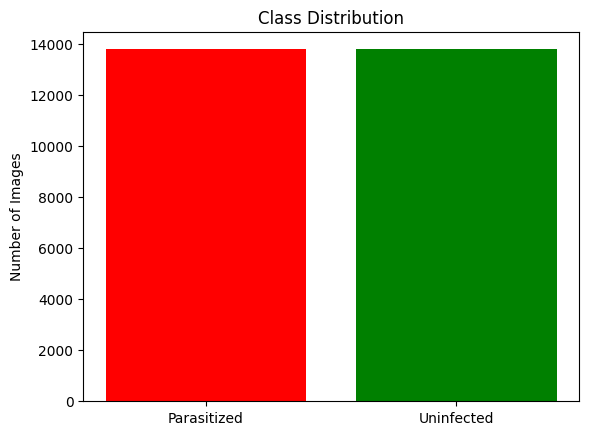

In [ ]:
# CLASS DISTRIBUTION

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set Paths
data_dir = 'cell_images'
parasitized_dir = os.path.join(data_dir, 'Parasitized')
uninfected_dir = os.path.join(data_dir, 'Uninfected')

num_parasitized = len(os.listdir(parasitized_dir))
num_uninfected = len(os.listdir(uninfected_dir))

plt.bar(['Parasitized', 'Uninfected'], [num_parasitized, num_uninfected], color=['red', 'green'])
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
# IMAGE DIMENSIONS
def get_dimensions_stats(folder, label, max_images=1000):
    heights = []
    widths = []
    for img_file in os.listdir(folder)[:max_images]:
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)
    return {
        'label': label,
        'height_mean': np.mean(heights),
        'height_std': np.std(heights),
        'height_min': np.min(heights),
        'height_max': np.max(heights),
        'width_mean': np.mean(widths),
        'width_std': np.std(widths),
        'width_min': np.min(widths),
        'width_max': np.max(widths),
        'num_images': len(heights)
    }


parasite_stats = get_dimensions_stats(parasitized_dir, 'Parasitized')
uninfected_stats = get_dimensions_stats(uninfected_dir, 'Uninfected')

stats_df = pd.DataFrame([parasite_stats, uninfected_stats])
stats_df = stats_df.set_index('label')

print("Image Dimension Statistics")
display(stats_df)


Image Dimension Statistics


,height_mean,height_std,height_min,height_max,width_mean,width_std,width_min,width_max,num_images
label,,,,,,,,,
Parasitized,133.552,21.946009,70,346,134.464,21.413330,64,265,1000
Uninfected,132.499,19.114288,76,214,131.200,18.503946,82,220,1000


100%|██████████| 1000/1000 [00:00<00:00, 2653.50it/s]


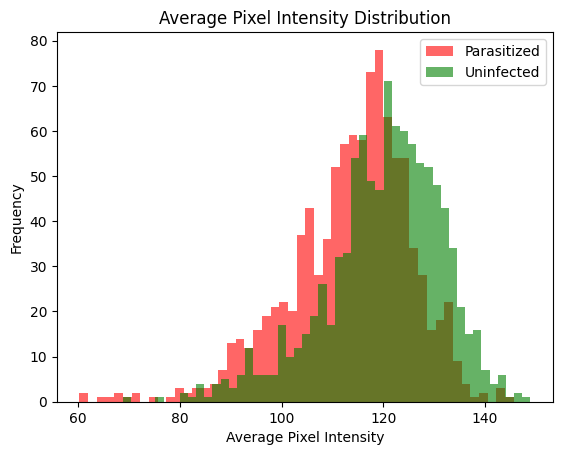

In [ ]:
# PIXEL INTENSITY
def avg_pixel_intensity(folder, label, n=1000):
    avg_intensities = []
    for img_file in tqdm(os.listdir(folder)[:n]):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            avg_intensities.append(np.mean(img))
    return avg_intensities

parasite_avg = avg_pixel_intensity(parasitized_dir, "Parasitized")
uninfected_avg = avg_pixel_intensity(uninfected_dir, "Uninfected")

# Plotting
plt.hist(parasite_avg, bins=50, alpha=0.6, label='Parasitized', color='red')
plt.hist(uninfected_avg, bins=50, alpha=0.6, label='Uninfected', color='green')
plt.title('Average Pixel Intensity Distribution')
plt.xlabel('Average Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 70.1 MB/s eta 0:00:00


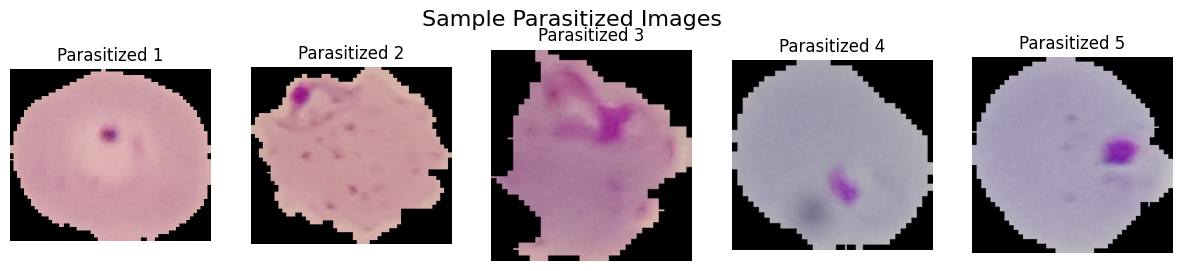

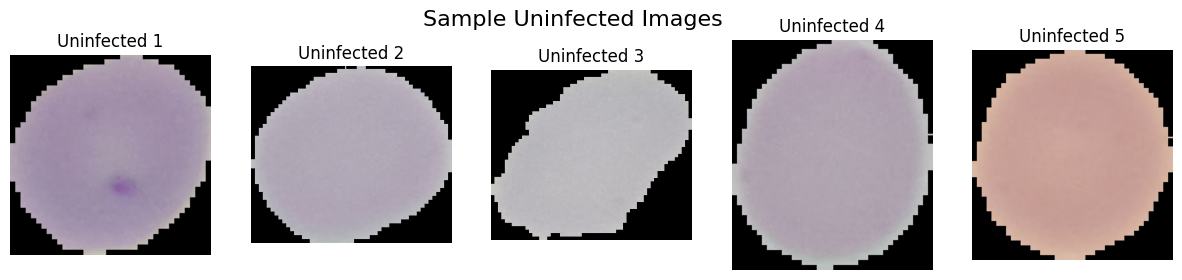

In [ ]:
# SAMPLE IMAGES

!pip install opencv-python
import cv2

def show_sample_images(folder, title, n=5):
    img_files = os.listdir(folder)[:n]
    plt.figure(figsize=(15, 3))
    for i, img_file in enumerate(img_files):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f'{title} {i+1}')
        plt.axis('off')
    plt.suptitle(f'Sample {title} Images', fontsize=16)
    plt.show()

show_sample_images(parasitized_dir, "Parasitized")
show_sample_images(uninfected_dir, "Uninfected")


**PREPROCESSING**

After exploring the dataset, the next step is to prepare the data for training the deep learning models. Images were sourced from two directories: ‘parasitized_dir’ containing infected cell images and uninfected_dir containing uninfected cells.

**Modifications**

Each image was opened using the Python Imaging Library (PIL) and converted to RGB format to ensure consistency. They were resized as well to 64×64 pixels for computational efficiency, and transformed into an array. These arrays were appended to a list with corresponding binary labels: 1 for parasitized and 0 for uninfected.

**Data** **Splitting**

To ensure fair model training and evaluation, the dataset was stratified and split into training, validation, and test sets using a 70/15/15 ratio. The training data was then shuffled randomly to eliminate any ordering bias.

**Data** **augmentation**

To improve generalization and prevent overfitting, data augmentation was applied using ImageDataGenerator from Keras. This technique introduces slight variations to the training images such as flipping, rotating, or zooming which helps the model generalize better and not just memorize the training data. This is especially important as we are working with an image dataset, as it allows the model to perform well on new, unseen images. This step helped to increase dataset variability and reduce the models' generalisation error (Goodfellow et al., 2016), which are common in microscopic imaging due to changes in lighting and focus.

**Normalization**

This was tailored to each model's requirements. For CNN, manual scaling was performed using ‘/255’ to normalize pixels to values between 0 and 1. On the other hand, ResNet50 and DenseNet121 used model-specific functions to match the original training distribution requirement of imageNet models. Using both methods ensured each model's preprocessing aligned with its architecture, while still enabling fair comparison through the consistent dataset partitions.



Overall, these preprocessing techniques ensured that the dataset was well-structured, standardized, and optimized for deep learning, thereby laying a robust foundation for model training and evaluation.


In [ ]:
# PREPROCESSING

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
import keras_tuner as kt
import random
import tensorflow as tf

# Set seed for reproducibility
seed_value = 92
np.random.seed(seed_value)
random.seed(seed_value)
tf.random.set_seed(seed_value)

# Parameters
image_dim = 64
batch_size = 32
dataset_path = '/content/cell_images/cell_images'

img_data = []
img_labels = []

for subdir, label in [(os.path.join(dataset_path, 'Parasitized'), 1),
                      (os.path.join(dataset_path, 'Uninfected'), 0)]:
    for filename in os.listdir(subdir):
        try:
            img_path = os.path.join(subdir, filename)
            img = Image.open(img_path).convert('RGB').resize((image_dim, image_dim))
            img_data.append(np.array(img))
            img_labels.append(label)
        except Exception as e:
            continue

features = np.array(img_data)
targets = np.array(img_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    features, targets, test_size=0.3, stratify=targets, random_state=seed_value
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed_value
)


print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")


train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: x / 255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=lambda x: x / 255.0)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=batch_size,
    shuffle=True,
    seed=seed_value
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test, y_test,
    batch_size=batch_size,
    shuffle=False
)



Train shape: (19290, 64, 64, 3), Validation shape: (4134, 64, 64, 3), Test shape: (4134, 64, 64, 3)


**MODEL DESIGN, TRAINING AND FINETUNING**

**CNN**

The CNN was designed from scratch using a basic yet effective structure. CNN is known to exhibit robustness and good performance on a large and realistic image set (Liang et al., 2016). This model served as a lightweight baseline, useful for comparing with more complex architectures. The architecture was easy to implement and computationally efficient.

The code incorporates the following, which are known to be best practices in CNN:

*   ReLU activation (effective for non-linearity).
*   MaxPooling: Reduces dimensionality and increases robustness.

*   Dropout: Regularization to prevent overfitting.

*   Adam optimizer: A robust and widely used optimizer.

*   Binary cross-entropy: Appropriate loss function for binary classification.


**ResNet50**

ResNet50 is a deep and well-established model known for its effectiveness in image recognition tasks. To adapt the ResNet50 model for the specific task of cell image classification, transfer learning was done. The pre-trained ResNet50 model was used as a feature extractor, leveraging its core knowledge. Firstly, the base ResNet50 layers were frozen to preserve these general features. Then, custom layers (Global Average Pooling, Dense, Dropout, and a final classification layer) were added on top and trained. Afterwards, a fine-tuning step was performed where some of the bottom layers of the ResNet50 model were unfrozen, allowing the model to further specialize its learned features to the parasitized vs. uninfected cell classification task, while still benefiting from the foundational knowledge encoded in the earlier layers.



**DenseNet121**

To efficiently adapt the DenseNet121 model for cell image classification, a transfer learning strategy was implemented. The pre-trained DenseNet121 model, having learned rich feature hierarchies from ImageNet, was utilized as a foundational feature extractor with its initial layers frozen. Custom classification layers, including Global Average Pooling, a tunable Dense layer with ReLU activation and Dropout, and a final sigmoid output layer, were added and trained to specialize in the parasitized versus uninfected classification task. This approach leverages the pre-existing knowledge of the deep network while allowing the newly added layers to learn task-specific patterns from the cell image data.


**Strengths of General Approach:**
1. Early Stopping was implemented which helps to prevent overfitting and saves training time by stopping when the model's performance on the validation set starts to degrade.
2. Train generator and val generator from ImageDataGenerator were used to load images in batches which saves memory.
3. The hyperparameters were tuned automatically using Keras Tuner. This helps automate the tedious process of manually trying different hyperparameter combinations, which can lead to a much better-performing model.
4. Transfer Learning leveraged the pre-trained weights of ResNet50 and DenseNet121. This allows the model use its already gained knowledge that solves one problem and apply them to solve the given task, potentially leading to faster convergence and better generalization (Elpeltagy and Sallam, 2021).
5. Seed was set for reproducibility.
6. Mixed precision training was also enabled which significantly reduces memory usage and accelerates model training without compromising accuracy (Micikevicius et al., 2017).


**Limitations of the General Approach**

* Having maximum trials = 3 provides a very small search space for Keras Tuner. It's unlikely that the absolute best hyperparameters were found.
* The images are resized to 64x64, which might lead to a loss of finer details that could be important for distinguishing between parasitized and uninfected cells.
* It was challenging finding the best finetuning techniques for the models.


In [ ]:
stop_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mixed_precision.set_global_policy('mixed_float16')

def define_cnn_model(hp):
    input_layer = Input((image_dim, image_dim, 3))
    x = input_layer
    for i in range(2):
        filters = hp.Int(f'filters_{i+1}', 32, 128, step=32)
        x = Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = MaxPooling2D()(x)
    x = Flatten()(x)
    x = Dense(hp.Int('dense_layer', 64, 256, step=64), activation='relu')(x)
    x = Dropout(hp.Float('drop_prob', 0.2, 0.5, step=0.1))(x)
    output_layer = Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(input_layer, output_layer)
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_tuner = kt.RandomSearch(
    define_cnn_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='cnn_tuner_folder',
    project_name='cnn_variant',
    seed = seed_value
)

cnn_tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)

best_cnn_model = cnn_tuner.get_best_models(1)[0]

cnn_history = best_cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)


Trial 3 Complete [00h 02m 53s]
val_accuracy: 0.9421867728233337

Best val_accuracy So Far: 0.9596033096313477
Total elapsed time: 00h 08m 08s
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9502 - loss: 0.1567 - val_accuracy: 0.9589 - val_loss: 0.1371
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9511 - loss: 0.1538 - val_accuracy: 0.9574 - val_loss: 0.1298
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9548 - loss: 0.1342 - val_accuracy: 0.9591 - val_loss: 0.1254
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9525 - loss: 0.1475 - val_accuracy: 0.9589 - val_loss: 0.1350
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9539 - loss: 0.1451 - val_accuracy: 0.9613 - val_loss: 0.1212
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9549 - loss: 0.1417 - val_accuracy: 0.9613 - val_loss: 0.1235
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9552 - loss: 0.1409 - val_accuracy: 0.9627 - val_loss: 0.1204
Epoch 8/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9562 - loss: 0.1306 - val_accurac

In [ ]:
# RESNET50
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import mixed_precision
import keras_tuner as kt

seed = 92
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

image_dim = 64
batch_size = 32

mixed_precision.set_global_policy('mixed_float16')

# Early stopping
stop_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True, seed=seed)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)
test_generator = val_datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)


def build_resnet_model(hp):
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(image_dim, image_dim, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(image_dim, image_dim, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu')(x)
    x = Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1))(x)
    outputs = Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


resnet_tuner = kt.RandomSearch(
    build_resnet_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='resnet_tuner_folder',
    project_name='resnet_64x64',
    seed=seed
)

resnet_tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)

best_resnet_model = resnet_tuner.get_best_models(num_models=1)[0]

base_model = best_resnet_model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

best_resnet_model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_history = best_resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)


Trial 3 Complete [00h 02m 13s]
val_accuracy: 0.8962264060974121

Best val_accuracy So Far: 0.9034833312034607
Total elapsed time: 00h 08m 16s
Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 111ms/step - accuracy: 0.8994 - loss: 0.2650 - val_accuracy: 0.9451 - val_loss: 0.1468
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.9368 - loss: 0.1877 - val_accuracy: 0.9560 - val_loss: 0.1261
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.9434 - loss: 0.1581 - val_accuracy: 0.9574 - val_loss: 0.1156
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.9486 - loss: 0.1507 - val_accuracy: 0.9591 - val_loss: 0.1136
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.9540 - loss: 0.1316 - val_accuracy: 0.9531 - val_loss: 0.1343
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.9536 - loss: 0.1298 - val_accuracy: 0.9632 - val_loss: 0.1042
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.955

In [ ]:
# DENSENET121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications.densenet import preprocess_input
import keras_tuner as kt
import random
import numpy as np
import tensorflow as tf

seed = 92
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test, y_test,
    batch_size=batch_size,
    shuffle=False
)

# mixed precision
mixed_precision.set_global_policy('mixed_float16')

# Early stopping
stop_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def build_densenet_model(hp):
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(image_dim, image_dim, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(image_dim, image_dim, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)

    x = Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu')(x)
    x = Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1))(x)

    outputs = Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

densenet_tuner = kt.RandomSearch(
    build_densenet_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='densenet_tuner_folder',
    project_name='densenet_variant',
    seed = seed
)

densenet_tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)

best_densenet_model = densenet_tuner.get_best_models(num_models=1)[0]

densenet_history = best_densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[stop_early],
    verbose=1
)


Trial 3 Complete [00h 08m 29s]
val_accuracy: 0.9296081066131592

Best val_accuracy So Far: 0.935413658618927
Total elapsed time: 00h 25m 32s
Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.9231 - loss: 0.2064 - val_accuracy: 0.9320 - val_loss: 0.1828
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9239 - loss: 0.2066 - val_accuracy: 0.9369 - val_loss: 0.1737
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9282 - loss: 0.1997 - val_accuracy: 0.9369 - val_loss: 0.1751
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9286 - loss: 0.1941 - val_accuracy: 0.9357 - val_loss: 0.1775
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9277 - loss: 0.1983 - val_accuracy: 0.9376 - val_loss: 0.1721
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.9250 - loss: 0.1981 - val_accuracy: 0.9332 - val_loss: 0.1787
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.9317 - loss

**EVALUATION AND COMPARISON**

All models were evaluated on the same test set using the following metrics:

* Accuracy

* Precision

* Recall

* F1-score

* Area Under the ROC Curve (AUC)


The ResNet50 model significantly outperformed both the CNN and DenseNet121 models across all metrics. ResNet50 achieved the highest accuracy (0.9601), precision (0.9648), recall (0.9550), F1-score (0.9599), and AUC (0.9920), demonstrating its superior ability to correctly classify parasitized and uninfected cell images and effectively balance precision and recall.

The CNN model showed reasonably good performance, with an accuracy of 0.8853, but it exhibited a noticeable drop in recall (0.7987) compared to ResNet50, indicating a higher rate of false negatives which is crucial in the field of medical diagnosis.

In contrast, the DenseNet121 model performed the poorest, with a lower accuracy (0.6824) and precision (0.6203), despite having a high recall (0.9405). This suggests that while DenseNet121 was good at correctly identifying most of the parasitized cells, it also produced a large number of false positives, leading to the low overall accuracy and precision. The low precision means a substantial number of uninfected cells are being incorrectly classified as parasitized. In a clinical setting, this would lead to serious problems when managing patients.

Overall, ResNet50 stands out as the most effective model for this cell image classification task based on these results.  

**Areas for Improvement**
* Small image size (64x64) may have limited the features and affected the performances, particularly for deeper models. The size could be increased to128x128 or 224x224 or higher (Sabottke and Spieler, 2020)
* Instead of using a fixed number of frozen layers, other fine-tuning strategies could be investigated to enhance performance.
* Hyperparameter tuning for DenseNet121 and CNN could be improved by using more sophisticated tuning algorithms within Keras Tuner, such as Bayesian Optimization, which can be more efficient than Random Search (Turner et al., 2021).
* Exploring deeper architectures, different filter sizes, and the addition of batch normalization for CNN.



>>> Evaluating CNN on Test Data
Test Accuracy: 88.53%
              precision    recall  f1-score   support

  Uninfected       0.83      0.97      0.89      2067
 Parasitized       0.97      0.80      0.87      2067

    accuracy                           0.89      4134
   macro avg       0.90      0.89      0.88      4134
weighted avg       0.90      0.89      0.88      4134



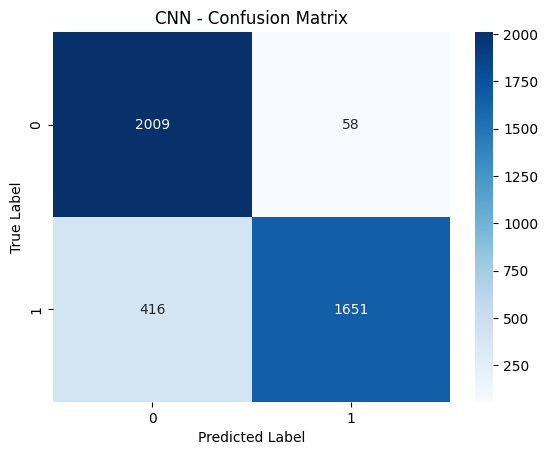

AUC Score: 0.90


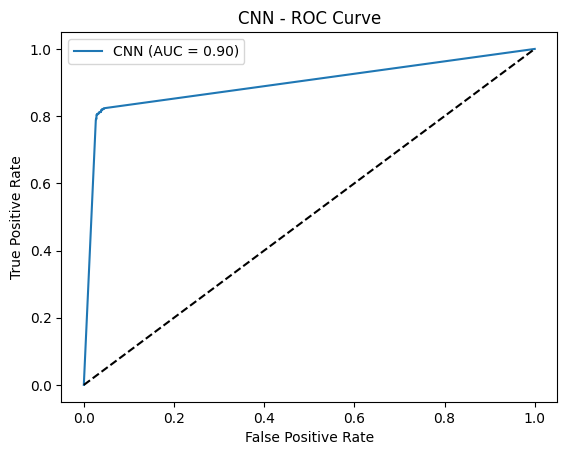


>>> Evaluating ResNet50 on Test Data
Test Accuracy: 96.01%
              precision    recall  f1-score   support

  Uninfected       0.96      0.97      0.96      2067
 Parasitized       0.96      0.96      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



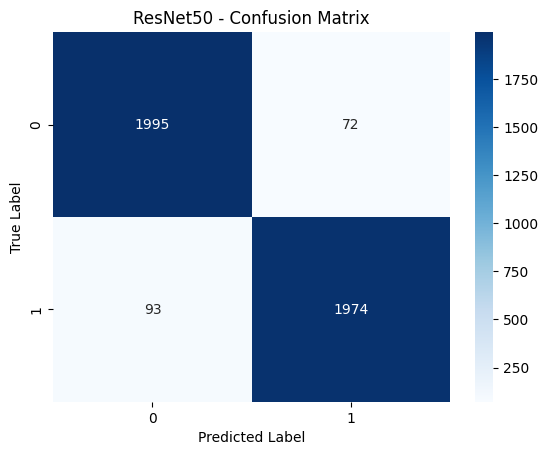

AUC Score: 0.99


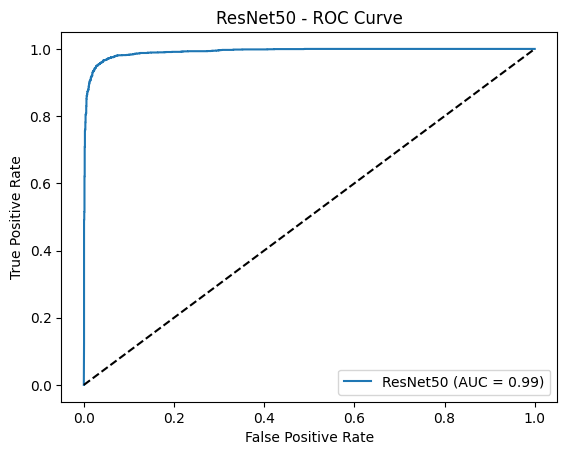


>>> Evaluating DenseNet121 on Test Data
Test Accuracy: 68.24%
              precision    recall  f1-score   support

  Uninfected       0.88      0.42      0.57      2067
 Parasitized       0.62      0.94      0.75      2067

    accuracy                           0.68      4134
   macro avg       0.75      0.68      0.66      4134
weighted avg       0.75      0.68      0.66      4134



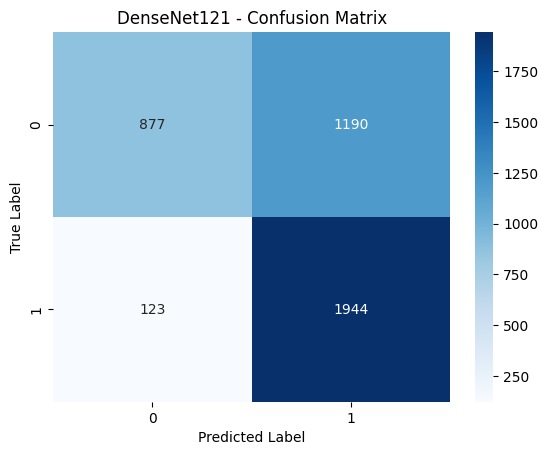

AUC Score: 0.77


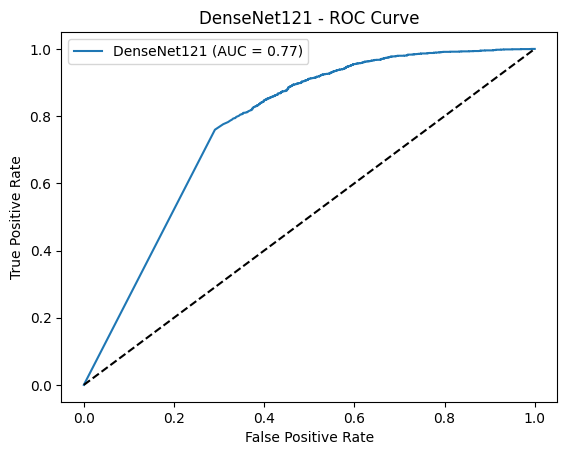


Model Performance Summary:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,CNN,0.8853,0.9661,0.7987,0.8745,0.8961
1,ResNet50,0.9601,0.9648,0.9550,0.9599,0.9920
2,DenseNet121,0.6824,0.6203,0.9405,0.7475,0.7736


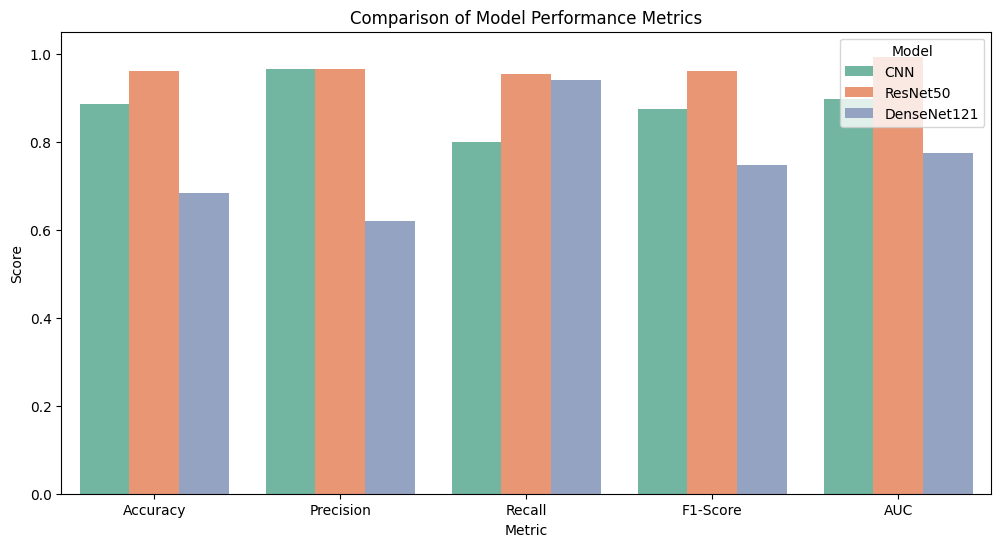

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

def assess_performance(model_name, model, generator, true_labels):
    print(f"\n>>> Evaluating {model_name} on Test Data")

    loss, accuracy = model.evaluate(generator, verbose=0)
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    generator.reset()
    total_steps = int(np.ceil(generator.n / generator.batch_size))
    probs = model.predict(generator, steps=total_steps, verbose=0).ravel()
    preds = (probs > 0.5).astype(int)

    print(classification_report(true_labels, preds, labels=[0, 1], target_names=['Uninfected', 'Parasitized']))

    # Confusion matrix
    matrix = confusion_matrix(true_labels, preds, labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(true_labels, probs)
    auc_score = auc(fpr, tpr)
    print(f"AUC Score: {auc_score:.2f}")
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

    # all key metrics
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(true_labels, preds), 4),
        'Precision': round(precision_score(true_labels, preds), 4),
        'Recall': round(recall_score(true_labels, preds), 4),
        'F1-Score': round(f1_score(true_labels, preds), 4),
        'AUC': round(roc_auc_score(true_labels, probs), 4)
    }

cnn_metrics = assess_performance("CNN", best_cnn_model, test_generator, y_test)
resnet_metrics = assess_performance("ResNet50", best_resnet_model, test_generator, y_test)
densenet_metrics = assess_performance("DenseNet121", best_densenet_model, test_generator, y_test)

metrics_df = pd.DataFrame([cnn_metrics, resnet_metrics, densenet_metrics])
print("\nModel Performance Summary:")
display(metrics_df)

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

plt.figure(figsize=(12, 6))
metrics_melted = metrics_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Score')

sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Comparison of Model Performance Metrics')
plt.ylim(0, 1.05)
plt.legend(title='Model')
plt.show()


**CONCLUSION**

In conclusion, this study involving the binary classification of cell images into parasitized and uninfected for malaria detection has emphasised the powerful application of deep learning techniques in healthcare. While the ResNet50 model demonstrated strong performance in classifying cell images, there are more avenues to explore for further improvement across all models. These include more extensive hyperparameter optimization, better suited image sizes especially for ResNet50 & DenseNet121, deeper investigation into model architectures and fine-tuning. Addressing the poor performances is particularly important for enhancing the overall reliability and effectiveness of the classification system

**REFERENCES**


Abukmeil, M., Ferrari, S., Genovese, A., Piuri, V. and Scotti, F., 2021. A survey of unsupervised generative models for exploratory data analysis and representation learning. ACM Computing Surveys (CSUR), 54(5), pp.1–40.

Elpeltagy, M. and Sallam, H., 2021. Automatic prediction of COVID−19 from chest images using modified ResNet50. Multimedia Tools and Applications, 80(17), pp.26451–26463.

Goodfellow, I., Bengio, Y. and Courville, A., 2016. Deep learning. Cambridge, MA: MIT Press.

LeCun, Y., Bengio, Y. and Hinton, G., 2015. Deep learning. Nature, 521(7553), pp.436–444.

Liang, Z., Powell, A., Ersoy, I. and Poostchi, M., 2016. CNN-based image analysis for malaria diagnosis. In: 2016 IEEE International Conference on Bioinformatics and Biomedicine (BIBM), Shenzhen, China. pp.493–496. DOI: 10.1109/BIBM.2016.7822567.

Micikevicius, P., Narang, S., Alben, J., Diamos, G., Elsen, E., Garcia, D., Ginsburg, B., Houston, M., Kuchaiev, O., Venkatesh, G. and Wu, H., 2017. Mixed precision training. arXiv preprint arXiv:1710.03740.

Sabottke, C.F. and Spieler, B.M., 2020. The effect of image resolution on deep learning in radiography. Radiology: Artificial Intelligence, 2(1), p.e190015.

Turner, R., Eriksson, D., McCourt, M., Kiili, J., Laaksonen, E., Xu, Z. and Guyon, I., 2021. Bayesian optimization is superior to random search for machine learning hyperparameter tuning: Analysis of the Black-Box Optimization Challenge 2020. Proceedings of the NeurIPS 2020 Competition and Demonstration Track. In: Proceedings of Machine Learning Research, 133, pp.3–26.

World Health Organization (WHO), 2016. Malaria microscopy quality assurance manual – version 2. Geneva: World Health Organization.

World Health Organization (WHO), 2022. World malaria report 2022. Geneva: World Health Organization.